In [1]:
import os
credential=os.environ['HF_TOKEN']

In [2]:
%%capture
%pip install --no-cache "data-prep-toolkit-transforms[readability]"
%pip install huggingface_hub
%pip install matplotlib

In [3]:
from huggingface_hub import hf_hub_download
import pandas as pd

REPO_ID = "HuggingFaceFW/fineweb"
FILENAME = "data/CC-MAIN-2013-20/000_00000.parquet"
file1 = hf_hub_download(repo_id=REPO_ID, filename=FILENAME, repo_type="dataset")
input_folder= os.path.dirname(file1)
indf=pd.read_parquet(file1)
indf.columns

/Users/touma/data-prep-kit-pkg/examples/notebooks/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Index(['text', 'id', 'dump', 'url', 'date', 'file_path', 'language',
       'language_score', 'token_count'],
      dtype='object')

<Axes: >

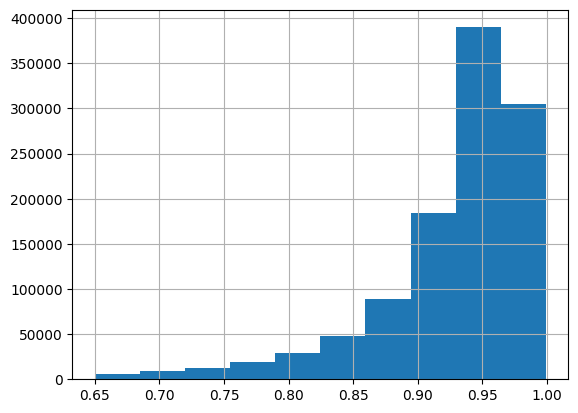

In [4]:
import matplotlib.pyplot as plt
indf['language_score'].hist()

In [5]:
%%time
from dpk_readability.runtime import Readability

Readability(
    input_folder=input_folder,
    output_folder="tmp/readabilty",
    readability_contents_column_name="text",
    readability_score_list=["mcalpine_eflaw_textstat"],
).transform()

11:26:22 INFO - Readability parameters are : {'readability_contents_column_name': 'text', 'readability_score_list': ['mcalpine_eflaw_textstat']}
11:26:22 INFO - pipeline id pipeline_id
11:26:22 INFO - code location None
11:26:22 INFO - data factory data_ is using local data access: input_folder - /Users/touma/.cache/huggingface/hub/datasets--HuggingFaceFW--fineweb/snapshots/0f039043b23fe1d4eed300b504aa4b4a68f1c7ba/data/CC-MAIN-2013-20 output_folder - tmp/readabilty
11:26:22 INFO - data factory data_ max_files -1, n_sample -1
11:26:22 INFO - data factory data_ Not using data sets, checkpointing False, max files -1, random samples -1, files to use ['.parquet'], files to checkpoint ['.parquet']
11:26:22 INFO - orchestrator readability started at 2025-05-13 11:26:22
11:26:22 INFO - Number of files is 1, source profile {'max_file_size': 2048.0454998016357, 'min_file_size': 2048.0454998016357, 'total_file_size': 2048.0454998016357}
11:32:15 INFO - Completed 1 files (100.0%) in 5.894 min
11:3

CPU times: user 4min 55s, sys: 17.1 s, total: 5min 12s
Wall time: 5min 53s


0

In [6]:
import pandas as pd
df = pd.read_parquet('tmp/readabilty/000_00000.parquet')

In [7]:
df.columns

Index(['text', 'id', 'dump', 'url', 'date', 'file_path', 'language',
       'language_score', 'token_count', 'mcalpine_eflaw_textstat'],
      dtype='object')

<Axes: >

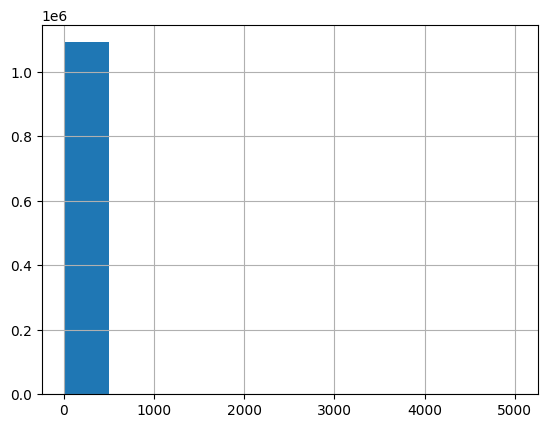

In [8]:
import matplotlib.pyplot as plt
df['mcalpine_eflaw_textstat'].hist()

In [9]:
#df['mcalpine_eflaw_textstat']

In [10]:
len(df[df['mcalpine_eflaw_textstat'] > 100])/len(df)

0.00046637517454709384

In [11]:
len(df[df['mcalpine_eflaw_textstat'] > 100])

509

In [12]:
len(df[df['mcalpine_eflaw_textstat'] < 100])

1090877

<Axes: >

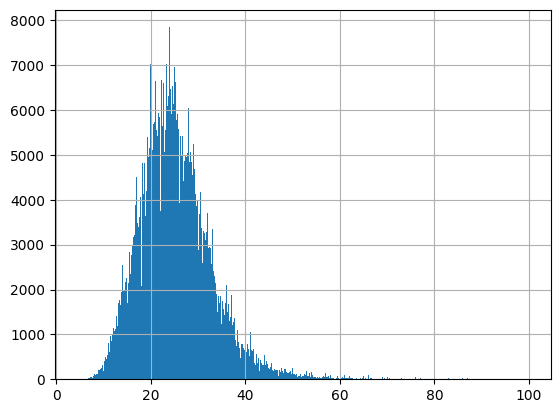

In [13]:
 df[df['mcalpine_eflaw_textstat']< 100]['mcalpine_eflaw_textstat'].hist(bins=1000)